#  Phase noise measurement plots - option 3 (LMK04828 in distribution mode)
FSWP settings (make sure to disable smoothing and spur removal):
* correlation factor = 2
* RBW = 10%
* Span = [1Hz, 1 MHz]

In [1]:
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import numpy as np
from IPython.display import SVG, Image
import matplotlib.pyplot as plt

In [2]:
data_info = {
    'inst_absolute': {
        'desc': 'Instrument Absolute Phase Noise',
        'data': 'data/option3/mo_dist.dat',
        'screenshot': 'data/option3/mo_dist.png',
        'diagram': 'diagrams/option3/inst_dist_absolute.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 3.19,
    },
    'inst_additive': {
        'desc': 'Instrument Additive Phase Noise',
        'data': 'data/option3/instrument_dist.dat',
        'screenshot': 'data/option3/instrument_dist.png',
        'diagram': 'diagrams/og/inst_dist_additive.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 3.68,
    },
    'lmk04828_absolute': {
        'desc': 'LMK4828B Absolute Phase Noise',
        'data': 'data/option3/lmk04828_mo_dist.dat',
        'screenshot': 'data/option3/lmk04828_mo_dist.png',
        'diagram': 'diagrams/option3/lmk04828_dis_absolute.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 2.58,
    },
    'lmk04828_additive': {
        'desc': 'LMK4828B Additive Phase Noise',
        'data': 'data/option3/lmk04828_fswp_dist.dat',
        'screenshot': 'data/option3/lmk04828_fswp_dist.png',
        'diagram': 'diagrams/option3/lmk04828_dist_additive.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 2.54,
    },
    'clk104_absolute': {
        'desc': 'CLK104 Absolute Phase Noise',
        'data': 'data/option3/clk104_mo_dist.dat',
        'screenshot': 'data/option3/clk104_mo_dist.png',
        'diagram': 'diagrams/option3/clk104_dist_absolute.drawio.svg',
        'f_c': 499.64e6 * 8,
        'power_dBm': -8.91,
    },
    'clk104_additive': {
        'desc': 'CLK104 Additive Phase Noise',
        'data': 'data/option3/clk104_fswp_dist.dat',
        'screenshot': 'data/option3/clk104_fswp_dist.png',
        'diagram': 'diagrams/option3/clk104_dist_additive.drawio.svg',
        'f_c': 499.64e6 * 8,
        'power_dBm': -8.90,
    },
    'dac_absolute': {
        'desc': 'RFSoC DAC Absolute Phase Noise',
        'data': 'data/option3/dac_mo_dist.dat',
        'screenshot': 'data/option3/dac_mo_dist.png',
        'diagram': 'diagrams/option3/dac_dist_absolute.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': -6.87,
    },
    'dac_additive': {
        'desc': 'RFSoC DAC Additive Phase Noise',
        'data': 'data/option3/dac_fswp_dist.dat',
        'screenshot': 'data/option3/dac_fswp_dist.png',
        'diagram': 'diagrams/option3/dac_dist_additive.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': -6.82,
    },
    'clk104_absolute_mod': {
        'desc': 'CLK104 Absolute Phase Noise with updated loop filter',
        'data': 'data/option3/clk104_mo_dist_mod.dat',
        'screenshot': 'data/option3/clk104_mo_dist_mod.png',
        'diagram': 'diagrams/option3/clk104_dist_absolute.drawio.svg',
        'f_c': 499.64e6 * 8,
        'power_dBm': -8.91,
    },
    'clk104_additive_mod': {
        'desc': 'CLK104 Additive Phase Noise with updated loop filter',
        'data': 'data/option3/clk104_fswp_mod.dat',
        'screenshot': 'data/option3/clk104_fswp_mod.png',
        'diagram': 'diagrams/option3/clk104_dist_additive.drawio.svg',
        'f_c': 499.64e6 * 8,
        'power_dBm': -8.90,
    },
    'dac_absolute_mod': {
        'desc': 'RFSoC DAC Absolute Phase Noise with updated loop filter',
        'data': 'data/option3/dac_mo_dist_mod.dat',
        'screenshot': 'data/option3/dac_mo_dist_mod.png',
        'diagram': 'diagrams/option3/dac_dist_absolute.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': -6.87,
    },
    'dac_additive_mod': {
        'desc': 'RFSoC DAC Additive Phase Noise with updated loop filter',
        'data': 'data/option3/dac_fswp_mod.dat',
        'screenshot': 'data/option3/dac_fswp_mod.png',
        'diagram': 'diagrams/option3/dac_dist_additive.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': -6.82,
    }
}

Load all data

In [3]:
def calc_cum_jitter(psd, f_off, f_c):
    """
    Calculate cumulative RMS time jitter from phase noise power.
    https://www.analog.com/media/en/training-seminars/tutorials/MT-008.pdf
    Arguments:
    psd: array of phase noise power [rad^2]
    f_off: array of offset frequency [Hz]
    f_c: carrier frequency [Hz]
    Returns: RMS time jitter [s]
    """
    ph_noise = cumulative_trapezoid(2 * 10**(psd/10), f_off, initial=0)
    return np.sqrt(ph_noise) / 2 / np.pi / f_c

dfs = []
for k, v in data_info.items():
    df = pd.read_csv(
        v['data'], sep=';', usecols=[0,1],
        skiprows=2, names=['Offset Freq [Hz]', k], index_col=0)
    df[k + '_jitter'] = calc_cum_jitter(df[k], df.index, v['f_c'])
    dfs.append(df)
df = pd.concat(dfs, axis=1)

# Instrument phase noise

* SMA100B Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/option3/inst_dist_absolute.drawio.svg)

* FSWP Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/option3/inst_dist_additive.drawio.svg)


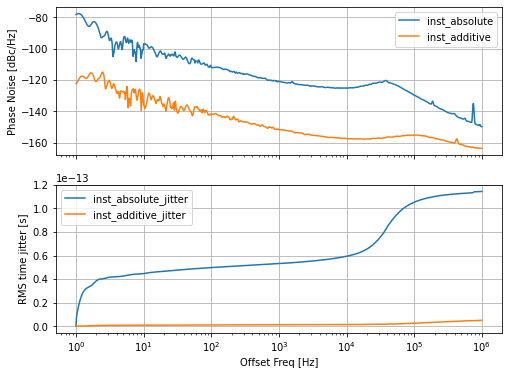

In [4]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['inst_absolute', 'inst_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['inst_absolute_jitter', 'inst_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [5]:
for k in ['inst_absolute_jitter', 'inst_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

inst_absolute_jitter RMS time jitter:   114.4 fs
inst_additive_jitter RMS time jitter:     5.0 fs


# LMK04828 phase noise - Distribution mode

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/option3/lmk04828_dist_absolute.drawio.svg)

* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/option3/lmk04828_dist_additive.drawio.svg)

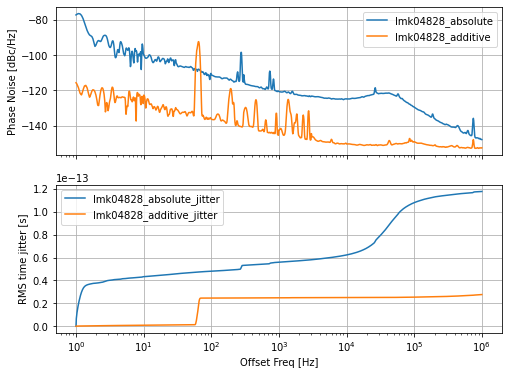

In [6]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['lmk04828_absolute', 'lmk04828_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['lmk04828_absolute_jitter', 'lmk04828_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [7]:
for k in ['lmk04828_absolute_jitter', 'lmk04828_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

lmk04828_absolute_jitter RMS time jitter:   117.7 fs
lmk04828_additive_jitter RMS time jitter:    27.7 fs


# CLK104 phase noise with default loop filter
C1 --> 1.8 nF<br>
C2 --> 180 nF<br>
C3 --> 2.2 nF<br>
R2 --> 180 ohm<br>
R3 --> 180 ohm<br>

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/option3/clk104_dist_absolute.drawio.svg)


* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/option3/clk104_dist_additive.drawio.svg)

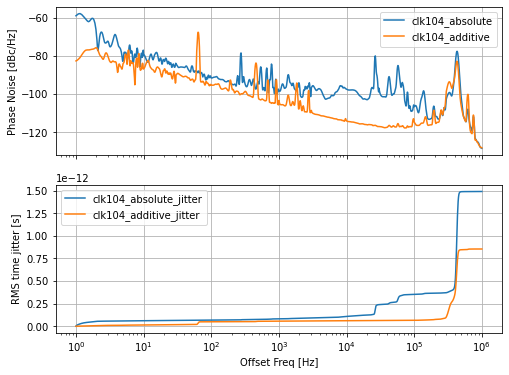

In [8]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['clk104_absolute', 'clk104_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['clk104_absolute_jitter', 'clk104_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [9]:
for k in ['clk104_absolute_jitter', 'clk104_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

clk104_absolute_jitter RMS time jitter:  1490.5 fs
clk104_additive_jitter RMS time jitter:   854.4 fs


# DAC phase noise

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/option3/dac_dist_absolute.drawio.svg)

* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/option3/dac_dist_additive.drawio.svg)

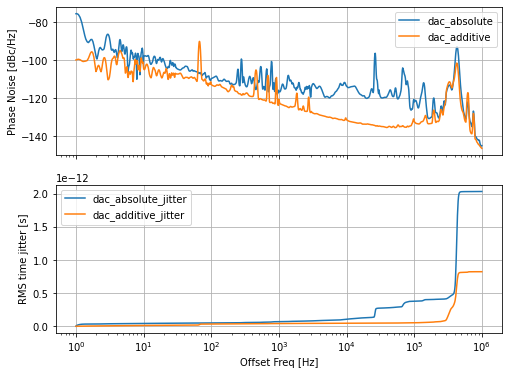

In [10]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['dac_absolute', 'dac_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['dac_absolute_jitter', 'dac_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [11]:
for k in ['dac_absolute_jitter', 'dac_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

dac_absolute_jitter RMS time jitter:  2039.0 fs
dac_additive_jitter RMS time jitter:   825.2 fs


# CLK104 phase noise with updated LMX2594 loop filter
C1 --> 10 nF<br>
C2 --> 1 uF<br>
C3 --> 3.3 nF<br>
R2 --> 27 ohm<br>
R3 --> 10 ohm<br>

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/option3/clk104_dist_absolute.drawio.svg)


* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/option3/clk104_dist_additive.drawio.svg)

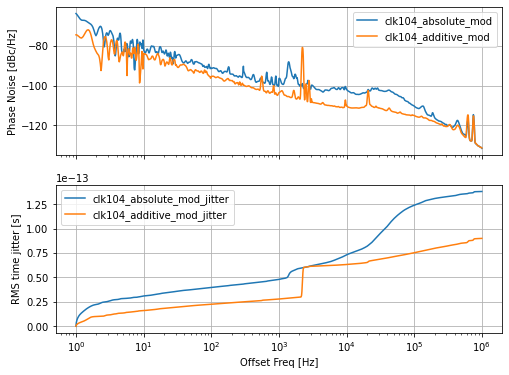

In [12]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['clk104_absolute_mod', 'clk104_additive_mod']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['clk104_absolute_mod_jitter', 'clk104_additive_mod_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [13]:
for k in ['clk104_absolute_mod_jitter', 'clk104_additive_mod_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

clk104_absolute_mod_jitter RMS time jitter:   138.0 fs
clk104_additive_mod_jitter RMS time jitter:    90.0 fs


# DAC phase noise with updated LMX2594 loop filter

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/option3/dac_dist_absolute.drawio.svg)

* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/option3/dac_dist_additive.drawio.svg)

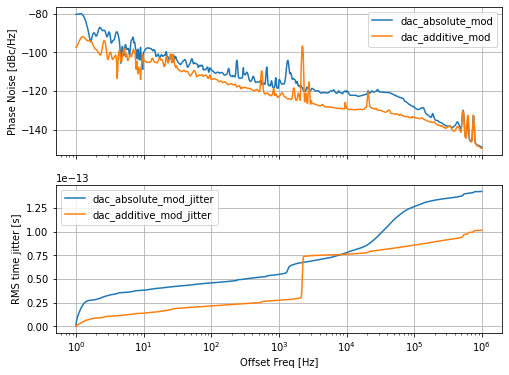

In [14]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['dac_absolute_mod', 'dac_additive_mod']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['dac_absolute_mod_jitter', 'dac_additive_mod_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [15]:
for k in ['dac_absolute_mod_jitter', 'dac_additive_mod_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

dac_absolute_mod_jitter RMS time jitter:   142.4 fs
dac_additive_mod_jitter RMS time jitter:   101.4 fs
